In [ ]:
!pip install transformers datasets evaluate deep-translator sentencepiece torch tqdm -q
!pip install gensim

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/College/CCI/CCI The Hack/Dataset/balanced_emotion_dataset_narrative.csv')
df = df[(df['label'] != 'love') & (df['narrative_text'])].copy()
print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 8170


,label,tweet,clean_text,narrative_text
0,anger,"Soal jalan Jatibaru,polisi tidak bisa GERTAK ...",soal jalan jatibaru polisi tidak gertak gubern...,"Jika kita perhatikan, soal jalan jatibaru poli..."
1,anger,"Sesama cewek lho (kayaknya), harusnya bisa le...",sesama cewek kayaknya harusnya lebih rasain si...,Saya ingin berbagi cerita tentang bagaimana se...
2,joy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto google s...,Kalimat ini menggambarkan pengalaman di mana k...
3,anger,"jalan Jatibaru,bagian dari wilayah Tn Abang.P...",jalan jatibaru bagian wilayah tn abang pengatu...,Ada momen menarik saat jalan jatibaru bagian w...
4,joy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman kemarin jam batalin tiket s...,Kalimat ini menggambarkan pengalaman di mana s...


In [ ]:
df_final = df[['label', 'narrative_text']]
df_final = df_final.rename(columns={'narrative_text': 'text'})
df_final.head()

,label,text
0,anger,"Jika kita perhatikan, soal jalan jatibaru poli..."
1,anger,Saya ingin berbagi cerita tentang bagaimana se...
2,joy,Kalimat ini menggambarkan pengalaman di mana k...
3,anger,Ada momen menarik saat jalan jatibaru bagian w...
4,joy,Kalimat ini menggambarkan pengalaman di mana s...


In [ ]:

labels = sorted(df_final["label"].unique().tolist())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df_final["label_encoded"] = df_final["label"].map(label2id)

train_df, test_df = np.split(df_final.sample(frac=1, random_state=42),
                             [int(0.8 * len(df_final))])

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label_encoded", "labels")
test_ds = test_ds.rename_column("label_encoded", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6536 [00:00<?, ? examples/s]

Map:   0%|          | 0/1634 [00:00<?, ? examples/s]

In [ ]:
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)
    f1 = metric_f1.compute(predictions=preds, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

In [ ]:
args = TrainingArguments(
    output_dir="/content/emotion_xlmr_local",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-1122053466.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: frazanhibriz2004 (frazanhibriz2004-telkom-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.905300,0.678690,0.769278,0.773318
2,0.687700,0.771066,0.821909,0.823454


TrainOutput(global_step=3268, training_loss=0.8351754681133144, metrics={'train_runtime': 5084.0182, 'train_samples_per_second': 2.571, 'train_steps_per_second': 0.643, 'total_flos': 1.2182289103650816e+16, 'train_loss': 0.8351754681133144, 'epoch': 2.0})

              precision    recall  f1-score   support

       anger       0.82      0.84      0.83       439
        fear       0.89      0.82      0.85       343
         joy       0.81      0.88      0.84       419
         sad       0.78      0.75      0.77       433

    accuracy                           0.82      1634
   macro avg       0.83      0.82      0.82      1634
weighted avg       0.82      0.82      0.82      1634



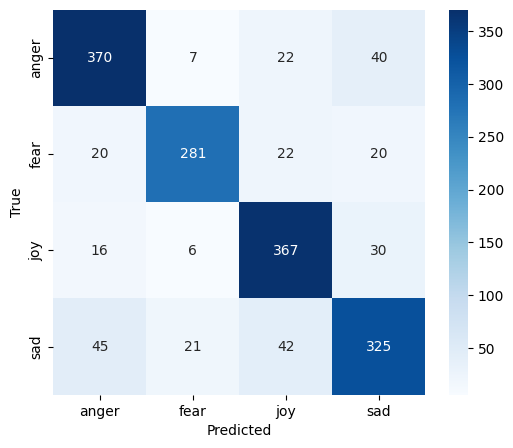

In [ ]:
preds = trainer.predict(test_ds)
pred_labels = np.argmax(preds.predictions, axis=1)
print(classification_report(test_df["label_encoded"], pred_labels, target_names=labels))

cm = confusion_matrix(test_df["label_encoded"], pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
save_path = "/content/drive/My Drive/College/CCI/CCI The Hack/Model/xlmr_journal_local_v1"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print("✅ Model & tokenizer saved to:", save_path)

✅ Model & tokenizer saved to: /content/drive/My Drive/College/CCI/CCI The Hack/Model/xlmr_journal_local_v1
